Dataset shape: (600, 2)


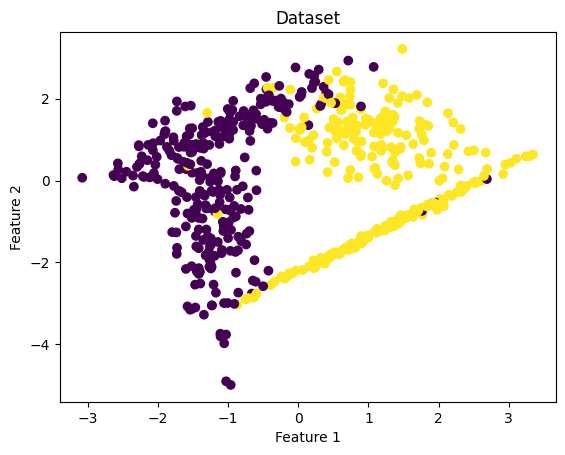

Small Tree Accuracy: 0.9444444444444444
Big Tree Accuracy: 0.9111111111111111


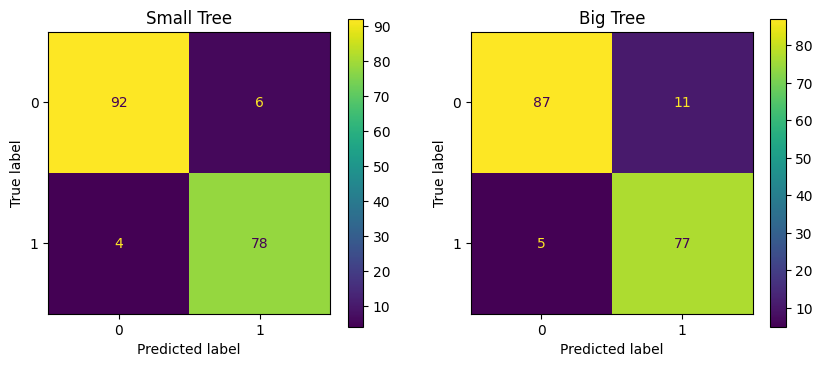

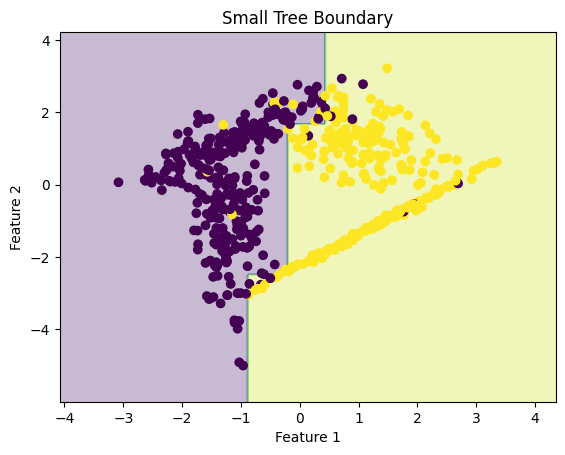

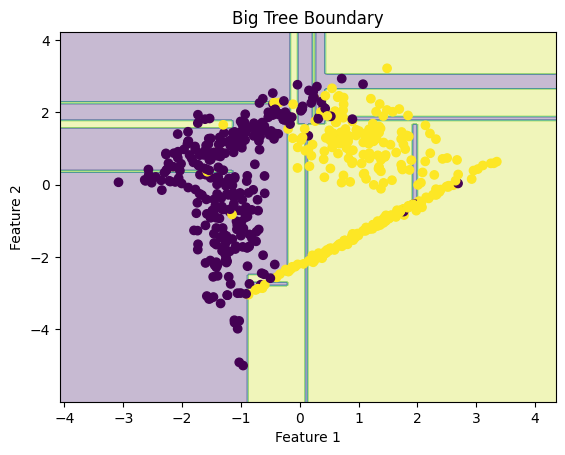

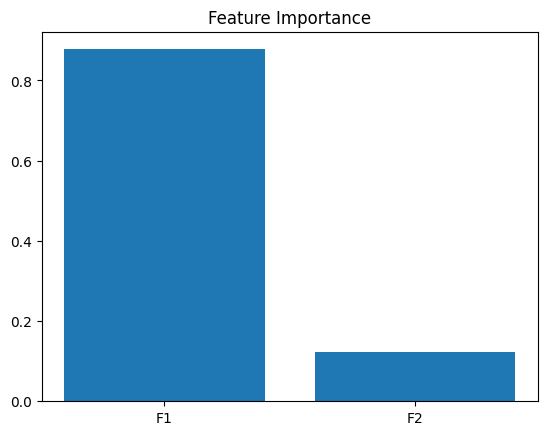

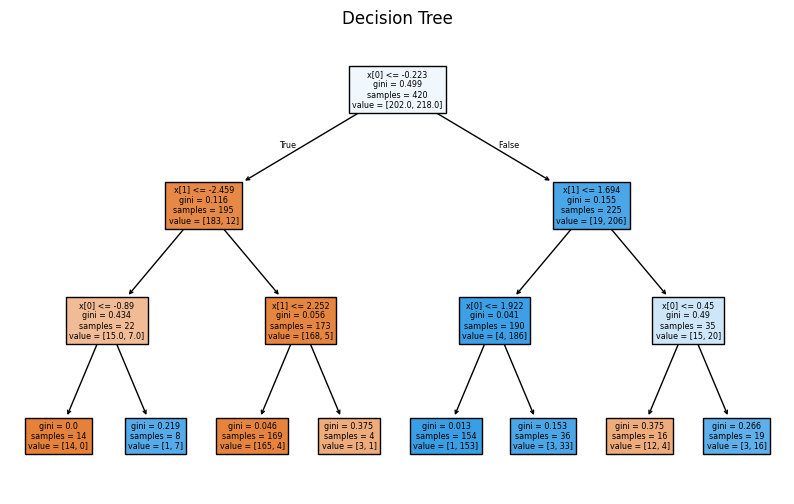

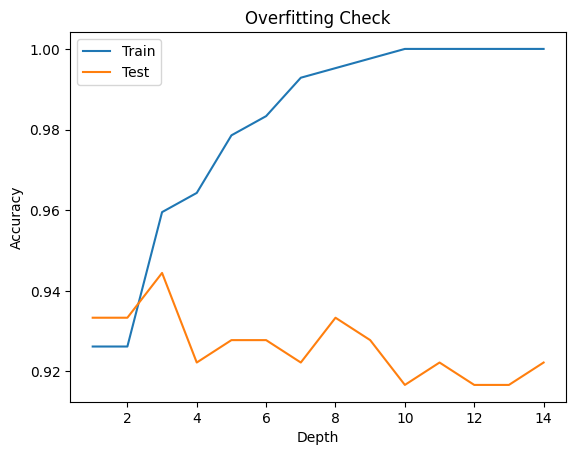

In [2]:
# 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# 2. Create Dataset
X, y = make_classification(
    n_samples=600,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=1.2,
    flip_y=0.05,
    random_state=42
)

print("Dataset shape:", X.shape)

# 3. Plot Dataset
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.savefig("dataset.png", dpi=300)
plt.show()


# 4. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# 5. Train Models
tree_small = DecisionTreeClassifier(max_depth=3)
tree_big = DecisionTreeClassifier()

tree_small.fit(X_train, y_train)
tree_big.fit(X_train, y_train)

# 6. Predictions
y_pred_small = tree_small.predict(X_test)
y_pred_big = tree_big.predict(X_test)


# 7. Accuracy
print("Small Tree Accuracy:", accuracy_score(y_test, y_pred_small))
print("Big Tree Accuracy:", accuracy_score(y_test, y_pred_big))

# 8. Confusion Matrix
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_small, ax=ax[0])
ax[0].set_title("Small Tree")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_big, ax=ax[1])
ax[1].set_title("Big Tree")

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()


# 9. Decision Boundary Function
def plot_boundary(model, X, y, title, filename):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y)

    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.savefig(filename, dpi=300)
    plt.show()

# 10. Plot Boundaries

plot_boundary(tree_small, X, y, "Small Tree Boundary", "small_tree.png")
plot_boundary(tree_big, X, y, "Big Tree Boundary", "big_tree.png")


# 11. Feature Importance
importance = tree_big.feature_importances_

plt.bar(["F1", "F2"], importance)
plt.title("Feature Importance")

plt.savefig("feature_importance.png", dpi=300)
plt.show()


# 12. Tree Plot
plt.figure(figsize=(10,6))
plot_tree(tree_small, filled=True)
plt.title("Decision Tree")

plt.savefig("tree.png", dpi=300)
plt.show()


# 13. Overfitting Check
depths = range(1, 15)
train_acc = []
test_acc = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(X_train, y_train)

    train_acc.append(accuracy_score(y_train, model.predict(X_train)))
    test_acc.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(depths, train_acc, label="Train")
plt.plot(depths, test_acc, label="Test")

plt.xlabel("Depth")
plt.ylabel("Accuracy")
plt.title("Overfitting Check")
plt.legend()

plt.savefig("overfitting.png", dpi=300)
plt.show()